In [1]:
import os

# Mengecek direktori saat ini
current_dir = os.getcwd()
print("Direktori awal:", current_dir)

# Jika masih di dalam folder 'notebooks', naik satu tingkat ke folder root proyek
if current_dir.endswith('notebooks'):
    os.chdir('..')
    print("Direktori setelah disesuaikan:", os.getcwd())


Direktori awal: d:\pokemon-tcg-classification\notebooks
Direktori setelah disesuaikan: d:\pokemon-tcg-classification


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalMaxPooling2D, Dropout, BatchNormalization, Cropping2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# ==========================================
# KONFIGURASI DIREKTORI & PARAMETER
# ==========================================
TRAIN_DIR = os.path.join('data', 'processed', 'train')
VAL_DIR = os.path.join('data', 'processed', 'val')
TEST_DIR = os.path.join('data', 'processed', 'test')

# Resolusi Tinggi untuk mempertahankan detail mikroskopis simbol set
IMG_HEIGHT = 588
IMG_WIDTH = 420
BATCH_SIZE = 16 
NUM_CLASSES = 10

# ==========================================
# DATA GENERATOR DENGAN PREPROCESS_INPUT NATIVE
# ==========================================
print("Menyiapkan Data Generator...")

# PENTING: rescale=1./255 dihapus, diganti dengan preprocess_input bawaan MobileNetV2
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    brightness_range=[0.8, 1.2] # Hanya augmentasi fotometrik
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# Menghitung bobot kelas untuk menangani ketidakseimbangan data
class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)


Menyiapkan Data Generator...
Found 1605 images belonging to 10 classes.
Found 340 images belonging to 10 classes.
Found 355 images belonging to 10 classes.
Class Weights: {0: np.float64(1.1145833333333333), 1: np.float64(0.9441176470588235), 2: np.float64(0.9786585365853658), 3: np.float64(1.2067669172932332), 4: np.float64(0.9331395348837209), 5: np.float64(0.823076923076923), 6: np.float64(0.9385964912280702), 7: np.float64(1.284), 8: np.float64(1.0354838709677419), 9: np.float64(0.9119318181818182)}


In [4]:
print("Membangun Arsitektur Internal Cropping (Resolusi Tinggi)...")

# 1. Definisi Input Gambar Utuh
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# 2. Layer Pemotong Internal (Membuang 55% atas dan 40% kanan)
top_crop = int(IMG_HEIGHT * 0.55)
bottom_crop = 0
left_crop = 0
right_crop = int(IMG_WIDTH * 0.40)

x = Cropping2D(cropping=((top_crop, bottom_crop), (left_crop, right_crop)), name='roi_cropping')(inputs)

# 3. Base Model MobileNetV2
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(None, None, 3) 
)
base_model.trainable = False 

x = base_model(x)

# 4. Global Max Pooling (Menangkap piksel paling tajam dari simbol)
x = GlobalMaxPooling2D()(x)

# 5. Layer Klasifikasi dengan Regularisasi Ketat
x = BatchNormalization()(x)
x = Dropout(0.6)(x) 
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.6)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()


Membangun Arsitektur Internal Cropping (Resolusi Tinggi)...


C:\Users\aryay\AppData\Local\Temp\ipykernel_12276\2669097833.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 588, 420, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ roi_cropping (Cropping2D)       │ (None, 265, 252, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 1280)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,610 (9.89 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [5]:
# --- TAHAP 1: FEATURE EXTRACTION ---
print("\n=== Memulai Tahap 1: Feature Extraction ===")
history_phase1 = model.fit(
    train_generator, 
    epochs=15, 
    validation_data=val_generator, 
    class_weight=class_weight_dict
)



=== Memulai Tahap 1: Feature Extraction ===
Epoch 1/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.1682 - loss: 8.4981 - val_accuracy: 0.2706 - val_loss: 6.5467
Epoch 2/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 86s 852ms/step - accuracy: 0.2293 - loss: 7.1151 - val_accuracy: 0.3118 - val_loss: 5.7200
Epoch 3/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 76s 755ms/step - accuracy: 0.2785 - loss: 6.2503 - val_accuracy: 0.3500 - val_loss: 5.2721
Epoch 4/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 79s 780ms/step - accuracy: 0.3165 - loss: 5.5670 - val_accuracy: 0.3676 - val_loss: 4.8406
Epoch 5/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 91s 907ms/step - accuracy: 0.3601 - loss: 4.9659 - val_accuracy: 0.3853 - val_loss: 4.4851
Epoch 6/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 98s 969ms/step - accuracy: 0.3794 - loss: 4.5233 - val_accuracy: 0.4059 - val_loss: 4.1298
Epoch 7/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 69s 687ms/step - accuracy: 0.3988 - loss: 4.0961 - val_accuracy: 0.4235 - val_loss: 3.8794
Epoch 8/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 

In [6]:
# --- TAHAP 2: FINE-TUNING TERUKUR ---
print("\n=== Memulai Tahap 2: Fine-Tuning Terukur ===")
base_model.trainable = True

# Membekukan 75% layer awal sesuai batasan skripsi
freeze_until = int(len(base_model.layers) * 0.75)
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

# Learning rate diperkecil secara signifikan agar distribusi bobot stabil
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Pengaturan Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

history_phase2 = model.fit(
    train_generator, 
    epochs=30, 
    validation_data=val_generator, 
    callbacks=[early_stop, reduce_lr], 
    class_weight=class_weight_dict
)



=== Memulai Tahap 2: Fine-Tuning Terukur ===
Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 105s 895ms/step - accuracy: 0.2604 - loss: 3.0548 - val_accuracy: 0.4235 - val_loss: 2.7052 - learning_rate: 5.0000e-05
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 82s 813ms/step - accuracy: 0.3421 - loss: 2.8260 - val_accuracy: 0.4147 - val_loss: 2.7404 - learning_rate: 5.0000e-05
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.4102 - loss: 2.6432
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
101/101 ━━━━━━━━━━━━━━━━━━━━ 75s 744ms/step - accuracy: 0.4069 - loss: 2.6481 - val_accuracy: 0.3971 - val_loss: 2.7222 - learning_rate: 5.0000e-05
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 77s 759ms/step - accuracy: 0.4617 - loss: 2.5286 - val_accuracy: 0.4088 - val_loss: 2.6862 - learning_rate: 2.5000e-05
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 75s 746ms/step - accuracy: 0.4916 - loss: 2.4872 - val_accuracy: 0.4324 - val_loss: 2.6288 - learning_rate: 2.5000e-05
Epoch

In [7]:
# Menyimpan model menggunakan format native Keras terbaru
os.makedirs('models', exist_ok=True)
model_path = os.path.join('models', 'mobilenetv2_pokemon_tcg.keras')
model.save(model_path)
print(f"Model berhasil disimpan di: {model_path}")


Model berhasil disimpan di: models\mobilenetv2_pokemon_tcg.keras


Mengevaluasi model pada Test Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 536ms/step - accuracy: 0.8254 - loss: 1.6319

Akurasi pada Test Set: 82.54%

=== Laporan Klasifikasi (Classification Report) ===
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 467ms/step
                       precision    recall  f1-score   support

                  151       1.00      0.78      0.88        32
      destined-rivals       1.00      0.87      0.93        38
       evolving-skies       0.94      0.92      0.93        36
     journey-together       0.86      0.83      0.84        29
          lost-origin       0.97      0.92      0.95        38
       paldea-evolved       0.69      0.86      0.76        43
        paldean-fates       0.94      0.87      0.90        38
 prismatic-evolutions       0.59      0.57      0.58        28
scarlet-violet-promos       0.82      0.79      0.81        34
       surging-sparks       0.61      0.77      0.68        39

             accuracy                           0.83       355
    

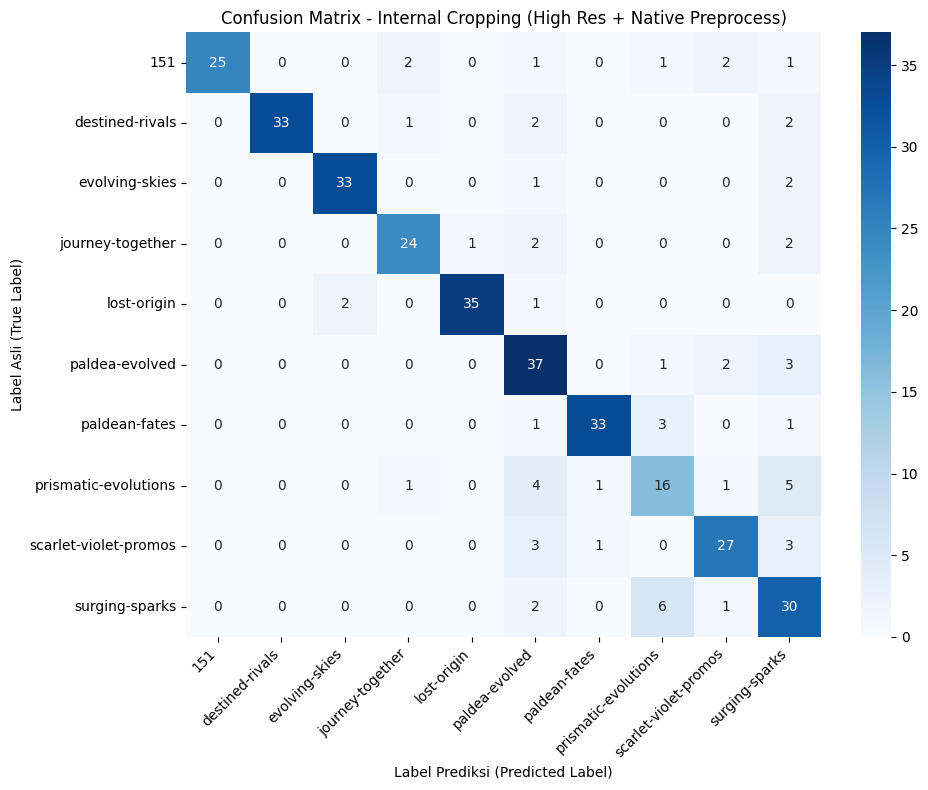

In [8]:
print("Mengevaluasi model pada Test Set...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nAkurasi pada Test Set: {test_acc * 100:.2f}%")

print("\n=== Laporan Klasifikasi (Classification Report) ===")
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Internal Cropping (High Res + Native Preprocess)')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Label Prediksi (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Menyimpan gambar Confusion Matrix
os.makedirs('reports', exist_ok=True)
cm_path = os.path.join('reports', 'confusion_matrix_mobilenet.png')
plt.savefig(cm_path)
print(f"Confusion Matrix berhasil disimpan di: {cm_path}")

plt.show()


Menghasilkan Learning Curves...
Learning Curves berhasil disimpan di: reports\learning_curves_mobilenet.png


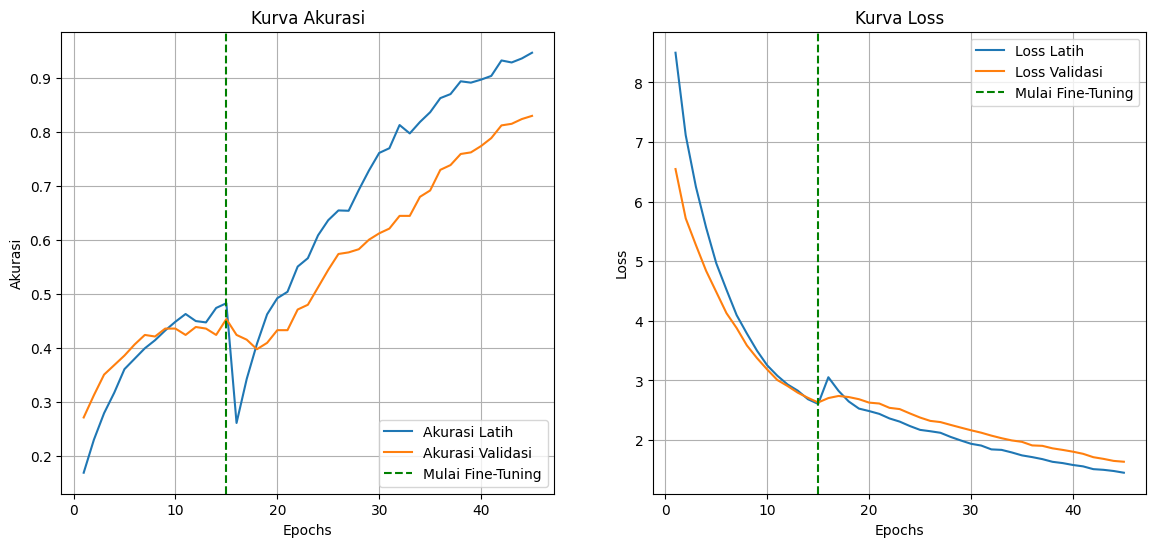

In [9]:
print("Menghasilkan Learning Curves...")

# Menggabungkan log dari Tahap 1 dan Tahap 2
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

initial_epochs = len(history_phase1.history['accuracy'])
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Latih')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Akurasi')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Latih')
plt.plot(epochs_range, val_loss, label='Loss Validasi')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

lc_path = os.path.join('reports', 'learning_curves_mobilenet.png')
plt.savefig(lc_path)
print(f"Learning Curves berhasil disimpan di: {lc_path}")

plt.show()
